# Huawei CNN-Attention Ablation Training

使用 datasets/processed/huawei/huawei_5s_1000bins_features.npz 进行 CNN attention 消融训练，包含：
- 数据集划分 (train/val/test = 0.7/0.15/0.15)
- 对重尾非负特征先做 log1p，再做 RobustScaler 预处理
- 训练与评估
- 默认评估当前训练得到的最优 checkpoint

In [14]:
import importlib
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.profiler import ProfilerActivity, profile
from torch.utils.data import DataLoader, TensorDataset

if (Path.cwd() / "training").exists():
    sys.path.append(str(Path.cwd() / "training"))
elif Path.cwd().name == "training":
    sys.path.append(str(Path.cwd()))

CONFIG = {
    "seed": 42,
    "cuda_device": None,
    "dataset_path": "../datasets/processed/huawei/huawei_5s_1000bins_features.npz",
    "model_module": "cnn_attention",
    "model_builder": "build_cnn_attention_model",
    "model_kwargs": {
        "stem_dropout": 0.15,
        "feature_dropout": 0.10,
        "pool_dropout": 0.10,
        "head_dropout": 0.35,
    },
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "batch_size": 64,
    "epochs": 120,
    "learning_rate": 6e-4,
    "weight_decay": 3e-4,
    "scheduler_factor": 0.5,
    "scheduler_patience": 6,
    "scheduler_min_lr": 1e-5,
    "early_stop_patience": 18,
    "label_smoothing": 0.04,
    "mixup_alpha": 0.20,
    "mixup_prob": 0.40,
    "input_noise_std": 0.004,
    "time_mask_prob": 0.10,
    "time_mask_ratio": 0.04,
    "grad_clip_norm": 1.0,
    "use_sam": True,
    "sam_rho": 0.05,
    "use_ema": True,
    "ema_decay": 0.999,
    "eval_with_ema": True,
    "save_ema_checkpoint": True,
    "best_metric": "val_loss",
    "report_clean_train_metrics": True,
    "model_save_name": "huawei_cnn_attention_best.pt",
    "eval_model_path": "./models/huawei_cnn_attention_best.pt",
    "log1p_features": [
        "pkt_count",
        "pkt_len_mean",
        "pkt_len_std",
        "last_pkt_global_iat",
        "uplink_pkt_len_sum",
        "downlink_pkt_len_sum",
        "uplink_pkt_count",
        "downlink_pkt_count",
    ],
}

if not np.isclose(CONFIG["train_ratio"] + CONFIG["val_ratio"] + CONFIG["test_ratio"], 1.0):
    raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")

SEED = int(CONFIG["seed"])
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    requested_cuda_device = CONFIG.get("cuda_device")
    if requested_cuda_device is not None:
        requested_cuda_device = int(requested_cuda_device)
        if requested_cuda_device >= torch.cuda.device_count():
            raise ValueError(f"Requested cuda_device={requested_cuda_device}, but only {torch.cuda.device_count()} device(s) are visible")
        torch.cuda.set_device(requested_cuda_device)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("CUDA device index:", torch.cuda.current_device())
print("Dataset:", CONFIG["dataset_path"])
print("Model:", f"{CONFIG['model_module']}.{CONFIG['model_builder']}")
print("Model kwargs:", CONFIG["model_kwargs"])
if CONFIG["eval_model_path"]:
    print("Evaluation checkpoint override:", CONFIG["eval_model_path"])
else:
    print("Evaluation checkpoint override: None (will use best checkpoint from this run)")
print("Generalization config:", {
    "label_smoothing": CONFIG["label_smoothing"],
    "mixup": (CONFIG["mixup_alpha"], CONFIG["mixup_prob"]),
    "noise_std": CONFIG["input_noise_std"],
    "time_mask": (CONFIG["time_mask_prob"], CONFIG["time_mask_ratio"]),
    "sam": (CONFIG["use_sam"], CONFIG["sam_rho"]),
    "ema": (CONFIG["use_ema"], CONFIG["ema_decay"]),
    "report_clean_train_metrics": CONFIG["report_clean_train_metrics"],
    "log1p_features": CONFIG["log1p_features"],
})

Using device: cuda
CUDA device index: 0
Dataset: ../datasets/processed/huawei/huawei_5s_1000bins_features.npz
Model: cnn_attention.build_cnn_attention_model
Model kwargs: {'stem_dropout': 0.15, 'feature_dropout': 0.1, 'pool_dropout': 0.1, 'head_dropout': 0.35}
Evaluation checkpoint override: ./models/huawei_cnn_attention_best.pt
Generalization config: {'label_smoothing': 0.04, 'mixup': (0.2, 0.4), 'noise_std': 0.004, 'time_mask': (0.1, 0.04), 'sam': (True, 0.05), 'ema': (True, 0.999), 'report_clean_train_metrics': True, 'log1p_features': ['pkt_count', 'pkt_len_mean', 'pkt_len_std', 'last_pkt_global_iat', 'uplink_pkt_len_sum', 'downlink_pkt_len_sum', 'uplink_pkt_count', 'downlink_pkt_count']}


In [2]:
data_path = Path(CONFIG["dataset_path"])
if not data_path.exists():
    raise FileNotFoundError(f"Cannot find dataset file: {data_path}")

data = np.load(data_path, allow_pickle=True)
X = data["X"].astype(np.float32)
y = data["y"].astype(np.int64)
classes = data["classes"] if "classes" in data.files else np.unique(y)
feature_names = (
    data["feature_names"].astype(str)
    if "feature_names" in data.files
    else np.array([f"feature_{i}" for i in range(X.shape[-1])], dtype=str)
 )

print("X shape:", X.shape)
print("y shape:", y.shape)
print("num classes:", len(classes), classes)
print("feature names:", feature_names.tolist())

X shape: (3200, 1000, 10)
y shape: (3200,)
num classes: 8 ['cloud_game' 'live' 'meeting' 'message' 'openlive' 'phone_game'
 'short_video' 'video']
feature names: ['pkt_count', 'pkt_len_mean', 'pkt_len_std', 'last_pkt_global_iat', 'time_offset_mean_norm', 'uplink_ratio', 'uplink_pkt_len_sum', 'downlink_pkt_len_sum', 'uplink_pkt_count', 'downlink_pkt_count']


In [3]:
test_ratio = float(CONFIG["test_ratio"])
val_ratio = float(CONFIG["val_ratio"])
remaining_ratio = 1.0 - test_ratio
val_ratio_within_temp = val_ratio / remaining_ratio

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=test_ratio, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_within_temp, random_state=SEED, stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (2239, 1000, 10) (2239,)
Val shape: (481, 1000, 10) (481,)
Test shape: (480, 1000, 10) (480,)


In [4]:
num_features = X_train.shape[-1]

feature_name_to_idx = {name: idx for idx, name in enumerate(feature_names.tolist())}
missing_log1p_features = [name for name in CONFIG["log1p_features"] if name not in feature_name_to_idx]
if missing_log1p_features:
    raise ValueError(f"Unknown log1p features: {missing_log1p_features}")

log1p_feature_indices = [feature_name_to_idx[name] for name in CONFIG["log1p_features"]]

def apply_log1p_transform(x3d, feature_indices):
    transformed = x3d.copy()
    if feature_indices:
        transformed[:, :, feature_indices] = np.log1p(np.clip(transformed[:, :, feature_indices], a_min=0.0, a_max=None))
    return transformed.astype(np.float32)

X_train_log = apply_log1p_transform(X_train, log1p_feature_indices)
X_val_log = apply_log1p_transform(X_val, log1p_feature_indices)
X_test_log = apply_log1p_transform(X_test, log1p_feature_indices)

scaler = RobustScaler(with_centering=True, with_scaling=True)
X_train_2d = X_train_log.reshape(-1, num_features)
scaler.fit(X_train_2d)

def apply_scaler(x3d):
    x2d = x3d.reshape(-1, num_features)
    x2d = scaler.transform(x2d)
    return x2d.reshape(x3d.shape).astype(np.float32)

X_train_scaled = apply_scaler(X_train_log)
X_val_scaled = apply_scaler(X_val_log)
X_test_scaled = apply_scaler(X_test_log)

print("Applied log1p to features:", CONFIG["log1p_features"])
print("Scaled train mean (approx):", X_train_scaled.mean(axis=(0, 1)))

Applied log1p to features: ['pkt_count', 'pkt_len_mean', 'pkt_len_std', 'last_pkt_global_iat', 'uplink_pkt_len_sum', 'downlink_pkt_len_sum', 'uplink_pkt_count', 'downlink_pkt_count']
Scaled train mean (approx): [0.3640149  1.3131924  0.55895454 0.27521262 0.10122527 0.11323868
 1.0439136  0.8864544  0.23788728 0.18675824]


In [5]:
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        if rho < 0.0:
            raise ValueError(f"Invalid rho value: {rho}")
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        if grad_norm == 0:
            if zero_grad:
                self.zero_grad()
            return
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None:
                    continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.sub_(self.state[p].get("e_w", 0.0))
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def step(self, closure=None):
        if closure is None:
            raise RuntimeError("SAM requires closure-based step, use first_step/second_step.")
        loss = closure()
        self.first_step(zero_grad=True)
        closure()
        self.second_step()
        return loss

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norms = []
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is not None:
                    norms.append(p.grad.norm(p=2).to(shared_device))
        if not norms:
            return torch.tensor(0.0, device=shared_device)
        return torch.norm(torch.stack(norms), p=2)


num_classes = len(np.unique(y))
model_module = importlib.import_module(CONFIG["model_module"])
model_builder = getattr(model_module, CONFIG["model_builder"])
model = model_builder(
    input_shape=X_train_scaled.shape[1:],
    num_classes=num_classes,
    **CONFIG["model_kwargs"],
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=float(CONFIG["label_smoothing"]))

if bool(CONFIG.get("use_sam", False)):
    optimizer = SAM(
        model.parameters(),
        AdamW,
        rho=float(CONFIG["sam_rho"]),
        lr=float(CONFIG["learning_rate"]),
        weight_decay=float(CONFIG["weight_decay"]),
    )
else:
    optimizer = AdamW(
        model.parameters(),
        lr=float(CONFIG["learning_rate"]),
        weight_decay=float(CONFIG["weight_decay"]),
    )

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=float(CONFIG["scheduler_factor"]),
    patience=int(CONFIG["scheduler_patience"]),
    min_lr=float(CONFIG["scheduler_min_lr"]),
)

num_params = sum(p.numel() for p in model.parameters())
print(model)
print("Total parameters:", num_params)
print("Loss:", criterion)
print("Optimizer:", type(optimizer).__name__)

CNNAttention(
  (feature_extractor): CNNFeatureExtractor(
    (block1): ConvBNAct(
      (conv): Conv1d(10, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU()
      (drop): Dropout(p=0.15, inplace=False)
    )
    (res1): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block2): ConvBNAct(
      (conv): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU()
      (drop): Dropout(p=0.15, inplace=False)
    )
    (res2): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
    (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (feature_dropout): Dropout1d(p=0.1, inplace=False)
  (attention_pool): AttentionPooling1D(
    (norm): LayerNorm((64,), 

In [6]:
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / str(CONFIG["model_save_name"])

train_dataset = TensorDataset(
    torch.from_numpy(X_train_scaled).float(), torch.from_numpy(y_train).long()
)
val_dataset = TensorDataset(
    torch.from_numpy(X_val_scaled).float(), torch.from_numpy(y_val).long()
)
test_dataset = TensorDataset(
    torch.from_numpy(X_test_scaled).float(), torch.from_numpy(y_test).long()
)

batch_size = int(CONFIG["batch_size"])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = float(decay)
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.detach().clone()

    @torch.no_grad()
    def update(self, model):
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            self.shadow[name].mul_(self.decay).add_(param.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def apply_shadow(self, model):
        self.backup = {}
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            self.backup[name] = param.detach().clone()
            param.data.copy_(self.shadow[name].data)

    @torch.no_grad()
    def restore(self, model):
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if name in self.backup:
                param.data.copy_(self.backup[name].data)
        self.backup = {}


def apply_time_mask(xb, mask_prob=0.2, mask_ratio=0.08):
    if mask_prob <= 0 or mask_ratio <= 0:
        return xb
    if np.random.rand() > mask_prob:
        return xb

    bsz, seq_len, _ = xb.shape
    mask_len = max(1, int(seq_len * mask_ratio))
    starts = torch.randint(0, seq_len - mask_len + 1, (bsz,), device=xb.device)

    for i in range(bsz):
        s = starts[i]
        xb[i, s : s + mask_len, :] = 0.0
    return xb


def mixup_batch(xb, yb, alpha=0.2):
    if alpha <= 0:
        return xb, yb, yb, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(xb.size(0), device=xb.device)
    mixed_xb = lam * xb + (1 - lam) * xb[index]
    y_a, y_b = yb, yb[index]
    return mixed_xb, y_a, y_b, lam


def run_epoch(model, loader, criterion, optimizer=None, apply_augment=False, apply_mixup=False, ema=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    use_sam = is_train and bool(CONFIG.get("use_sam", False)) and hasattr(optimizer, "first_step")

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        use_mixup = False

        if is_train:
            optimizer.zero_grad()

            if apply_augment:
                noise_std = float(CONFIG["input_noise_std"])
                if noise_std > 0:
                    xb = xb + torch.randn_like(xb) * noise_std
                xb = apply_time_mask(
                    xb,
                    mask_prob=float(CONFIG["time_mask_prob"]),
                    mask_ratio=float(CONFIG["time_mask_ratio"]),
                )

            if apply_mixup:
                use_mixup = np.random.rand() < float(CONFIG["mixup_prob"])
                if use_mixup:
                    xb, y_a, y_b, lam = mixup_batch(xb, yb, alpha=float(CONFIG["mixup_alpha"]))

        if is_train and use_sam:
            logits = model(xb)
            if use_mixup:
                loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
            else:
                loss = criterion(logits, yb)
            loss.backward()

            clip_norm = float(CONFIG["grad_clip_norm"])
            if clip_norm > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            optimizer.first_step(zero_grad=True)

            logits_second = model(xb)
            if use_mixup:
                loss_second = lam * criterion(logits_second, y_a) + (1 - lam) * criterion(logits_second, y_b)
            else:
                loss_second = criterion(logits_second, yb)
            loss_second.backward()

            if clip_norm > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            optimizer.second_step(zero_grad=True)

            logits_for_metrics = logits.detach()
            loss_for_log = loss.detach()
        else:
            with torch.set_grad_enabled(is_train):
                logits = model(xb)
                if is_train and use_mixup:
                    loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
                else:
                    loss = criterion(logits, yb)
                if is_train:
                    loss.backward()
                    clip_norm = float(CONFIG["grad_clip_norm"])
                    if clip_norm > 0:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
                    optimizer.step()

            logits_for_metrics = logits.detach()
            loss_for_log = loss.detach()

        if is_train and ema is not None:
            ema.update(model)

        running_loss += loss_for_log.item() * yb.size(0)
        preds = logits_for_metrics.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    return running_loss / total, correct / total


def get_current_lr(opt):
    if hasattr(opt, "base_optimizer"):
        return float(opt.base_optimizer.param_groups[0]["lr"])
    return float(opt.param_groups[0]["lr"])


print("Prepared datasets and dataloaders:")
print("  train batches:", len(train_loader))
print("  val batches:", len(val_loader))
print("  test batches:", len(test_loader))
print("Training artifacts will be saved to:", best_model_path.resolve())

Prepared datasets and dataloaders:
  train batches: 35
  val batches: 8
  test batches: 8
Training artifacts will be saved to: /home/ronghanj/dev/network-traffic-classification/training/models/huawei_cnn_attention_best.pt


In [16]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_metric_name = str(CONFIG["best_metric"])
best_val_acc = -1.0
best_val_loss = float("inf")
early_stop_patience = int(CONFIG["early_stop_patience"])
early_stop_counter = 0
num_epochs = int(CONFIG["epochs"])
report_clean_train = bool(CONFIG.get("report_clean_train_metrics", True))

use_ema = bool(CONFIG.get("use_ema", False))
ema = ModelEMA(model, decay=float(CONFIG.get("ema_decay", 0.999))) if use_ema else None
eval_with_ema = bool(CONFIG.get("eval_with_ema", False))
save_ema_ckpt = bool(CONFIG.get("save_ema_checkpoint", True))

for epoch in range(1, num_epochs + 1):
    train_loss_aug, _ = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        apply_augment=True,
        apply_mixup=True,
        ema=ema,
    )

    if report_clean_train:
        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=None,
            apply_augment=False,
            apply_mixup=False,
            ema=None,
        )
    else:
        train_loss, train_acc = train_loss_aug, float("nan")

    if eval_with_ema and ema is not None:
        ema.apply_shadow(model)
        val_loss, val_acc = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            apply_augment=False,
            apply_mixup=False,
            ema=None,
        )
        ema.restore(model)
    else:
        val_loss, val_acc = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            apply_augment=False,
            apply_mixup=False,
            ema=None,
        )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = get_current_lr(optimizer)
    print(
        f"Epoch {epoch:03d}/{num_epochs} | "
        f"lr={current_lr:.6f} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if best_metric_name == "val_loss":
        is_better = val_loss < best_val_loss
    else:
        is_better = val_acc > best_val_acc

    if is_better:
        best_val_acc = val_acc
        best_val_loss = val_loss
        early_stop_counter = 0

        if save_ema_ckpt and ema is not None:
            ema.apply_shadow(model)
            torch.save(model.state_dict(), best_model_path)
            ema.restore(model)
        else:
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Saved best model to {best_model_path} "
            f"(val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f})"
        )
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

Epoch 001/120 | lr=0.000600 | train_loss=0.3637 train_acc=0.9589 | val_loss=0.5230 val_acc=0.8898
Saved best model to models/huawei_cnn_attention_best.pt (val_loss=0.5230, val_acc=0.8898)
Epoch 002/120 | lr=0.000600 | train_loss=0.3637 train_acc=0.9571 | val_loss=0.5125 val_acc=0.8960
Saved best model to models/huawei_cnn_attention_best.pt (val_loss=0.5125, val_acc=0.8960)
Epoch 003/120 | lr=0.000600 | train_loss=0.3620 train_acc=0.9611 | val_loss=0.5024 val_acc=0.8960
Saved best model to models/huawei_cnn_attention_best.pt (val_loss=0.5024, val_acc=0.8960)
Epoch 004/120 | lr=0.000600 | train_loss=0.3575 train_acc=0.9567 | val_loss=0.5222 val_acc=0.8836
Epoch 005/120 | lr=0.000600 | train_loss=0.3563 train_acc=0.9603 | val_loss=0.5088 val_acc=0.8940
Epoch 006/120 | lr=0.000600 | train_loss=0.3600 train_acc=0.9625 | val_loss=0.5022 val_acc=0.9085
Saved best model to models/huawei_cnn_attention_best.pt (val_loss=0.5022, val_acc=0.9085)
Epoch 007/120 | lr=0.000600 | train_loss=0.3646 trai

Loaded checkpoint: /home/ronghanj/dev/network-traffic-classification/training/models/huawei_cnn_attention_best.pt
Parameters: 21,353 (0.021 M)
Trainable parameters: 21,353 (0.021 M)
Approx. FLOPs per sample: 2,173,888
Approx. MACs per sample: 1,086,944 (1.087 M)
Test loss: 0.4695 | Test accuracy: 0.9083

Classification Report:

              precision    recall  f1-score   support

  cloud_game     0.7703    0.9500    0.8507        60
        live     0.9815    0.8833    0.9298        60
     meeting     0.8966    0.8667    0.8814        60
     message     0.9032    0.9333    0.9180        60
    openlive     0.9672    0.9833    0.9752        60
  phone_game     0.9355    0.9667    0.9508        60
 short_video     0.9434    0.8333    0.8850        60
       video     0.9107    0.8500    0.8793        60

    accuracy                         0.9083       480
   macro avg     0.9135    0.9083    0.9088       480
weighted avg     0.9135    0.9083    0.9088       480

Confusion Matrix:
 

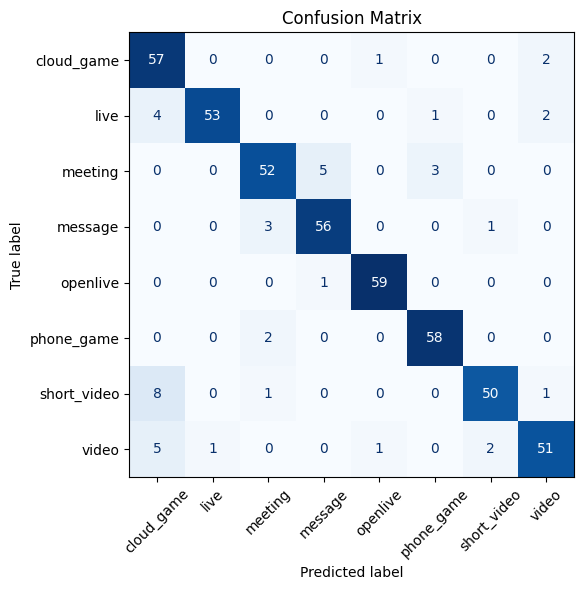

In [17]:
def resolve_checkpoint_path(path_str):
    checkpoint_path = Path(path_str)
    if checkpoint_path.is_absolute():
        return checkpoint_path.resolve()

    candidates = []
    if Path.cwd().name == "training":
        candidates.append((Path.cwd() / checkpoint_path).resolve())
    elif (Path.cwd() / "training").exists():
        candidates.append((Path.cwd() / "training" / checkpoint_path).resolve())
    candidates.append((Path.cwd() / checkpoint_path).resolve())

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def load_checkpoint_state_dict(checkpoint_path, map_location):
    checkpoint = torch.load(checkpoint_path, map_location=map_location)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]
    return checkpoint


def profile_model_macs(model_path):
    profile_model = model_builder(
        input_shape=X_train_scaled.shape[1:],
        num_classes=num_classes,
        **CONFIG["model_kwargs"],
    ).cpu()
    profile_model.load_state_dict(load_checkpoint_state_dict(model_path, map_location="cpu"))
    profile_model.eval()

    example_input = torch.randn(1, *X_train_scaled.shape[1:], dtype=torch.float32)
    with profile(activities=[ProfilerActivity.CPU], with_flops=True, record_shapes=False, acc_events=True) as prof:
        with torch.no_grad():
            _ = profile_model(example_input)

    total_flops = sum(getattr(event, "flops", 0) for event in prof.key_averages())
    total_macs = total_flops / 2 if total_flops else float("nan")
    return total_flops, total_macs


eval_model_path = resolve_checkpoint_path(CONFIG["eval_model_path"])
if not eval_model_path.exists():
    raise FileNotFoundError(f"Cannot find checkpoint file: {eval_model_path}")

best_model = model_builder(
    input_shape=X_train_scaled.shape[1:],
    num_classes=num_classes,
    **CONFIG["model_kwargs"],
).to(device)
state_dict = load_checkpoint_state_dict(eval_model_path, map_location=device)
best_model.load_state_dict(state_dict)
best_model.eval()

num_params = sum(param.numel() for param in best_model.parameters())
num_trainable_params = sum(param.numel() for param in best_model.parameters() if param.requires_grad)
total_flops, total_macs = profile_model_macs(eval_model_path)

print(f"Loaded checkpoint: {eval_model_path}")
print(f"Parameters: {num_params:,} ({num_params / 1e6:.3f} M)")
print(f"Trainable parameters: {num_trainable_params:,} ({num_trainable_params / 1e6:.3f} M)")
if np.isfinite(total_macs):
    print(f"Approx. FLOPs per sample: {total_flops:,.0f}")
    print(f"Approx. MACs per sample: {total_macs:,.0f} ({total_macs / 1e6:.3f} M)")
else:
    print("Approx. MACs per sample: unavailable")

test_loss, test_acc = run_epoch(best_model, test_loader, criterion, optimizer=None)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        all_preds.append(preds)
        all_targets.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_targets)

target_names = [str(c) for c in classes]
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)
ax.set_title("Confusion Matrix")
fig.tight_layout()
plt.show()

In [ ]:
print(f"Best model save path: {best_model_path.resolve()}")
if "eval_model_path" in globals():
    print(f"Evaluation checkpoint path: {eval_model_path}")